In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from sklearn.model_selection import train_test_split 
from sklearn.preprocessing import StandardScaler 
from sklearn.preprocessing import MinMaxScaler 
from sklearn.preprocessing import LabelEncoder 
from sklearn.linear_model import LinearRegression 
from sklearn.metrics import r2_score 

## CARREGAMENTO DOS DADOS


In [3]:
df  = pd.read_csv("data/gold/dados_limpos.csv")
df = df.drop(columns=['CODIGO_CLIENTE', 'DATA_UPLOAD', 'ARQUIVO_FONTE', 'DATA_TRATAMENTO'])
df.head(5)

,UF,IDADE,ESCOLARIDADE,ESTADO_CIVIL,QT_FILHOS,CASA_PROPRIA,QT_IMOVEIS,VL_IMOVEIS,OUTRA_RENDA,OUTRA_RENDA_VALOR,TEMPO_ULTIMO_EMPREGO_MESES,TRABALHANDO_ATUALMENTE,ULTIMO_SALARIO,QT_CARROS,VALOR_TABELA_CARROS,SCORE,RENDA_TOTAL,FAIXA_ETARIA,TEM_FILHOS,CATEGORIA_RENDA
0,SP,19,Superior Cursando,Solteiro,0,False,0,0.0,False,0.0,8,True,1800.0,0,0.0,12,1800.0,Até 20,Não,Baixa
1,MG,23,Superior Completo,Solteiro,1,False,0,0.0,False,0.0,9,False,4800.0,1,50000.0,18,4800.0,21 a 30,Sim,Média-Baixa
2,SC,25,Segundo Grau Completo,Casado,0,True,1,220000.0,False,0.0,18,True,2200.0,2,30000.0,23,2200.0,21 a 30,Não,Baixa
3,PR,27,Superior Cursando,Casado,1,True,0,0.0,False,0.0,22,False,3900.0,0,0.0,28,3900.0,21 a 30,Sim,Média-Baixa
4,RJ,28,Superior Completo,Divorciado,2,False,1,370000.0,False,0.0,30,True,6100.0,1,35000.0,34,6100.0,21 a 30,Sim,Média


## INSPEÇÃO INICIAL 

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10476 entries, 0 to 10475
Data columns (total 20 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   UF                          10476 non-null  object 
 1   IDADE                       10476 non-null  int64  
 2   ESCOLARIDADE                10476 non-null  object 
 3   ESTADO_CIVIL                10476 non-null  object 
 4   QT_FILHOS                   10476 non-null  int64  
 5   CASA_PROPRIA                10476 non-null  bool   
 6   QT_IMOVEIS                  10476 non-null  int64  
 7   VL_IMOVEIS                  10476 non-null  float64
 8   OUTRA_RENDA                 10476 non-null  bool   
 9   OUTRA_RENDA_VALOR           10476 non-null  float64
 10  TEMPO_ULTIMO_EMPREGO_MESES  10476 non-null  int64  
 11  TRABALHANDO_ATUALMENTE      10476 non-null  bool   
 12  ULTIMO_SALARIO              10476 non-null  float64
 13  QT_CARROS                   104

In [5]:
bool_cols = df.select_dtypes(include="bool").columns
df[bool_cols] = df[bool_cols].astype(int)

In [6]:
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10476 entries, 0 to 10475
Data columns (total 20 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   UF                          10476 non-null  object 
 1   IDADE                       10476 non-null  int64  
 2   ESCOLARIDADE                10476 non-null  object 
 3   ESTADO_CIVIL                10476 non-null  object 
 4   QT_FILHOS                   10476 non-null  int64  
 5   CASA_PROPRIA                10476 non-null  int64  
 6   QT_IMOVEIS                  10476 non-null  int64  
 7   VL_IMOVEIS                  10476 non-null  float64
 8   OUTRA_RENDA                 10476 non-null  int64  
 9   OUTRA_RENDA_VALOR           10476 non-null  float64
 10  TEMPO_ULTIMO_EMPREGO_MESES  10476 non-null  int64  
 11  TRABALHANDO_ATUALMENTE      10476 non-null  int64  
 12  ULTIMO_SALARIO              10476 non-null  float64
 13  QT_CARROS                   104

,IDADE,QT_FILHOS,CASA_PROPRIA,QT_IMOVEIS,VL_IMOVEIS,OUTRA_RENDA,OUTRA_RENDA_VALOR,TEMPO_ULTIMO_EMPREGO_MESES,TRABALHANDO_ATUALMENTE,ULTIMO_SALARIO,QT_CARROS,VALOR_TABELA_CARROS,SCORE,RENDA_TOTAL
count,10476.000000,10476.000000,10476.000000,10476.000000,10476.000000,10476.000000,10476.000000,10476.000000,10476.000000,10476.000000,10476.000000,10476.000000,10476.000000,10476.000000
mean,41.054124,1.115120,0.453608,0.847079,238453.608247,0.202749,641.237113,43.070447,0.604811,8286.531119,0.936426,40996.563574,50.743986,8927.768232
std,13.878162,0.974969,0.497867,0.957374,265843.934416,0.402066,1295.978195,40.851521,0.488915,5826.589775,0.806635,47404.214062,27.223715,6242.971817
min,19.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,8.000000,0.000000,1800.000000,0.000000,0.000000,12.000000,1800.000000
25%,28.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,14.000000,0.000000,3900.000000,0.000000,0.000000,28.000000,3900.000000
50%,42.000000,1.000000,0.000000,1.000000,185000.000000,0.000000,0.000000,22.000000,1.000000,6100.000000,1.000000,35000.000000,45.000000,8500.000000
75%,53.000000,2.000000,1.000000,1.000000,370000.000000,0.000000,0.000000,75.000000,1.000000,11500.000000,2.000000,50000.000000,72.000000,11500.000000
max,65.000000,3.000000,1.000000,3.000000,900000.000000,1.000000,4000.000000,150.000000,1.000000,22000.000000,2.000000,180000.000000,98.000000,24400.000000


In [7]:
df.isnull().sum()

UF                            0
IDADE                         0
ESCOLARIDADE                  0
ESTADO_CIVIL                  0
QT_FILHOS                     0
CASA_PROPRIA                  0
QT_IMOVEIS                    0
VL_IMOVEIS                    0
OUTRA_RENDA                   0
OUTRA_RENDA_VALOR             0
TEMPO_ULTIMO_EMPREGO_MESES    0
TRABALHANDO_ATUALMENTE        0
ULTIMO_SALARIO                0
QT_CARROS                     0
VALOR_TABELA_CARROS           0
SCORE                         0
RENDA_TOTAL                   0
FAIXA_ETARIA                  0
TEM_FILHOS                    0
CATEGORIA_RENDA               0
dtype: int64

## ANÁLISE EXPLORATÓRIA (EDA)

In [8]:
num = df[['IDADE', 'QT_FILHOS', 'QT_IMOVEIS', 'VL_IMOVEIS', 'OUTRA_RENDA_VALOR', 'TEMPO_ULTIMO_EMPREGO_MESES', 'ULTIMO_SALARIO', 'QT_CARROS', 'VALOR_TABELA_CARROS', 'SCORE', 'RENDA_TOTAL']]


In [9]:
cat = df.drop(columns=['IDADE', 'QT_FILHOS', 'QT_IMOVEIS', 'VL_IMOVEIS', 'OUTRA_RENDA_VALOR', 'TEMPO_ULTIMO_EMPREGO_MESES', 'ULTIMO_SALARIO', 'QT_CARROS', 'VALOR_TABELA_CARROS', 'SCORE', 'RENDA_TOTAL'])

In [10]:
print(num)

       IDADE  QT_FILHOS  QT_IMOVEIS  VL_IMOVEIS  OUTRA_RENDA_VALOR  \
0         19          0           0         0.0                0.0   
1         23          1           0         0.0                0.0   
2         25          0           1    220000.0                0.0   
3         27          1           0         0.0                0.0   
4         28          2           1    370000.0                0.0   
...      ...        ...         ...         ...                ...   
10471     51          1           0         0.0                0.0   
10472     48          0           1    220000.0                0.0   
10473     51          1           0         0.0                0.0   
10474     48          2           1    370000.0                0.0   
10475     51          0           0         0.0                0.0   

       TEMPO_ULTIMO_EMPREGO_MESES  ULTIMO_SALARIO  QT_CARROS  \
0                               8          1800.0          0   
1                              

In [11]:
print(cat)

       UF           ESCOLARIDADE ESTADO_CIVIL  CASA_PROPRIA  OUTRA_RENDA  \
0      SP      Superior Cursando     Solteiro             0            0   
1      MG      Superior Completo     Solteiro             0            0   
2      SC  Segundo Grau Completo       Casado             1            0   
3      PR      Superior Cursando       Casado             1            0   
4      RJ      Superior Completo   Divorciado             0            0   
...    ..                    ...          ...           ...          ...   
10471  PR      Superior Completo     Solteiro             0            0   
10472  SP  Segundo Grau Completo       Casado             1            0   
10473  RJ      Superior Cursando       Casado             1            0   
10474  RJ      Superior Completo   Divorciado             0            0   
10475  PR  Segundo Grau Completo   Divorciado             0            0   

       TRABALHANDO_ATUALMENTE FAIXA_ETARIA TEM_FILHOS CATEGORIA_RENDA  
0              

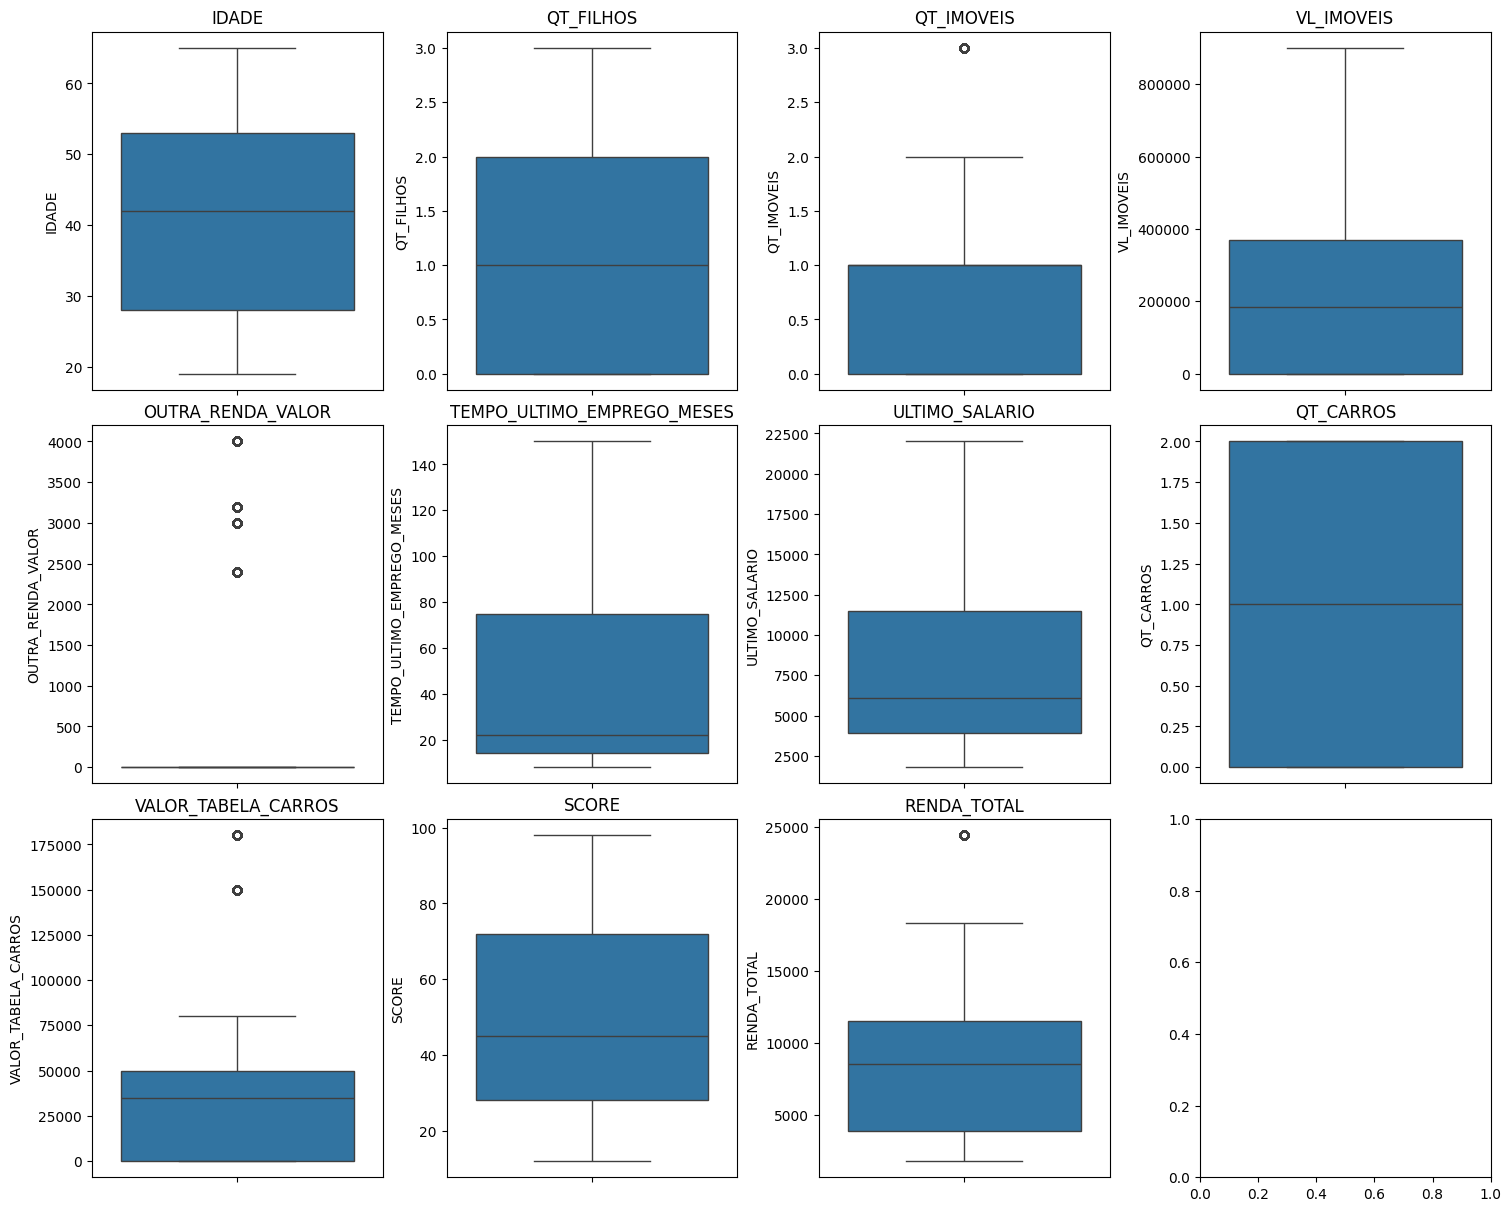

In [12]:
fig, axes = plt.subplots(3, 4, figsize=(15, 12), constrained_layout=True)

for ax, col in zip(axes.flat, num):
    sns.boxplot(data=df, y=col, ax=ax)
    ax.set_title(col)

for ax in axes.flat[len(num):]:
    ax.set_visible(False)

plt.show()

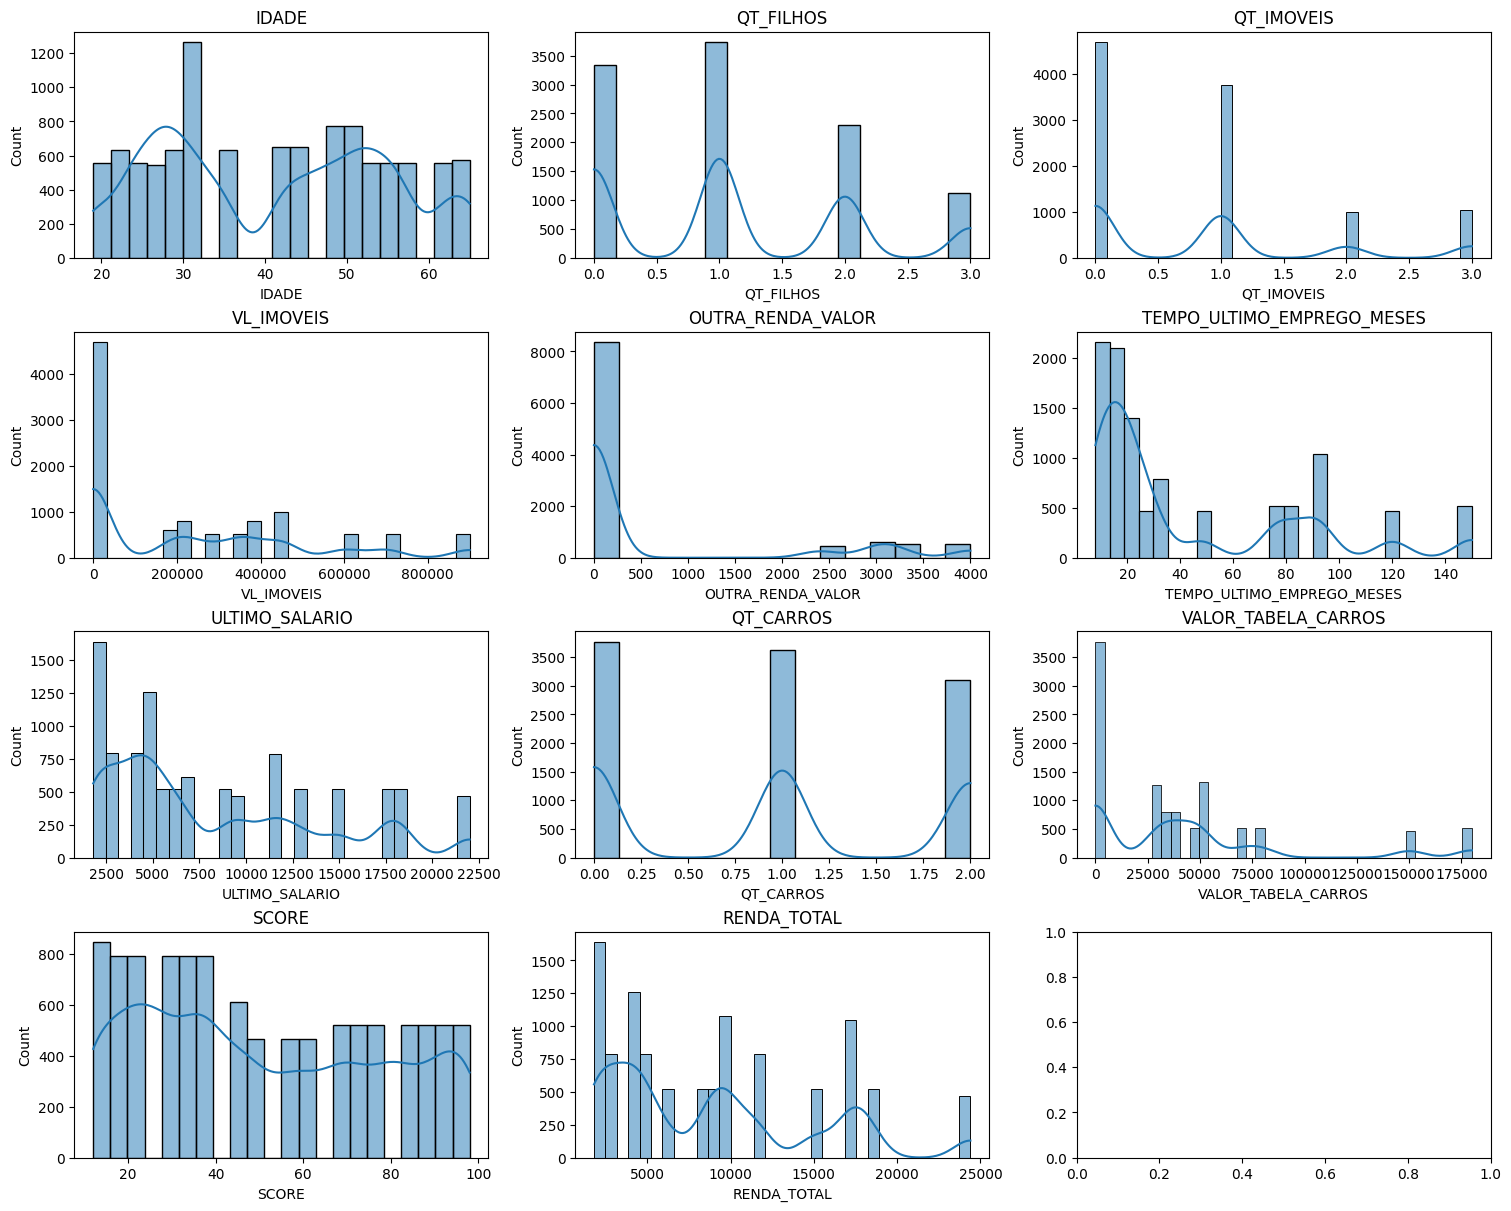

In [13]:
fig, axes = plt.subplots(4, 3, figsize=(15, 12), constrained_layout=True)

for ax, col in zip(axes.flat, num):
    sns.histplot(data=df, x=col, ax=ax, kde=True)
    ax.set_title(col)

for ax in axes.flat[len(num):]:
    ax.set_visible(False)

plt.show()

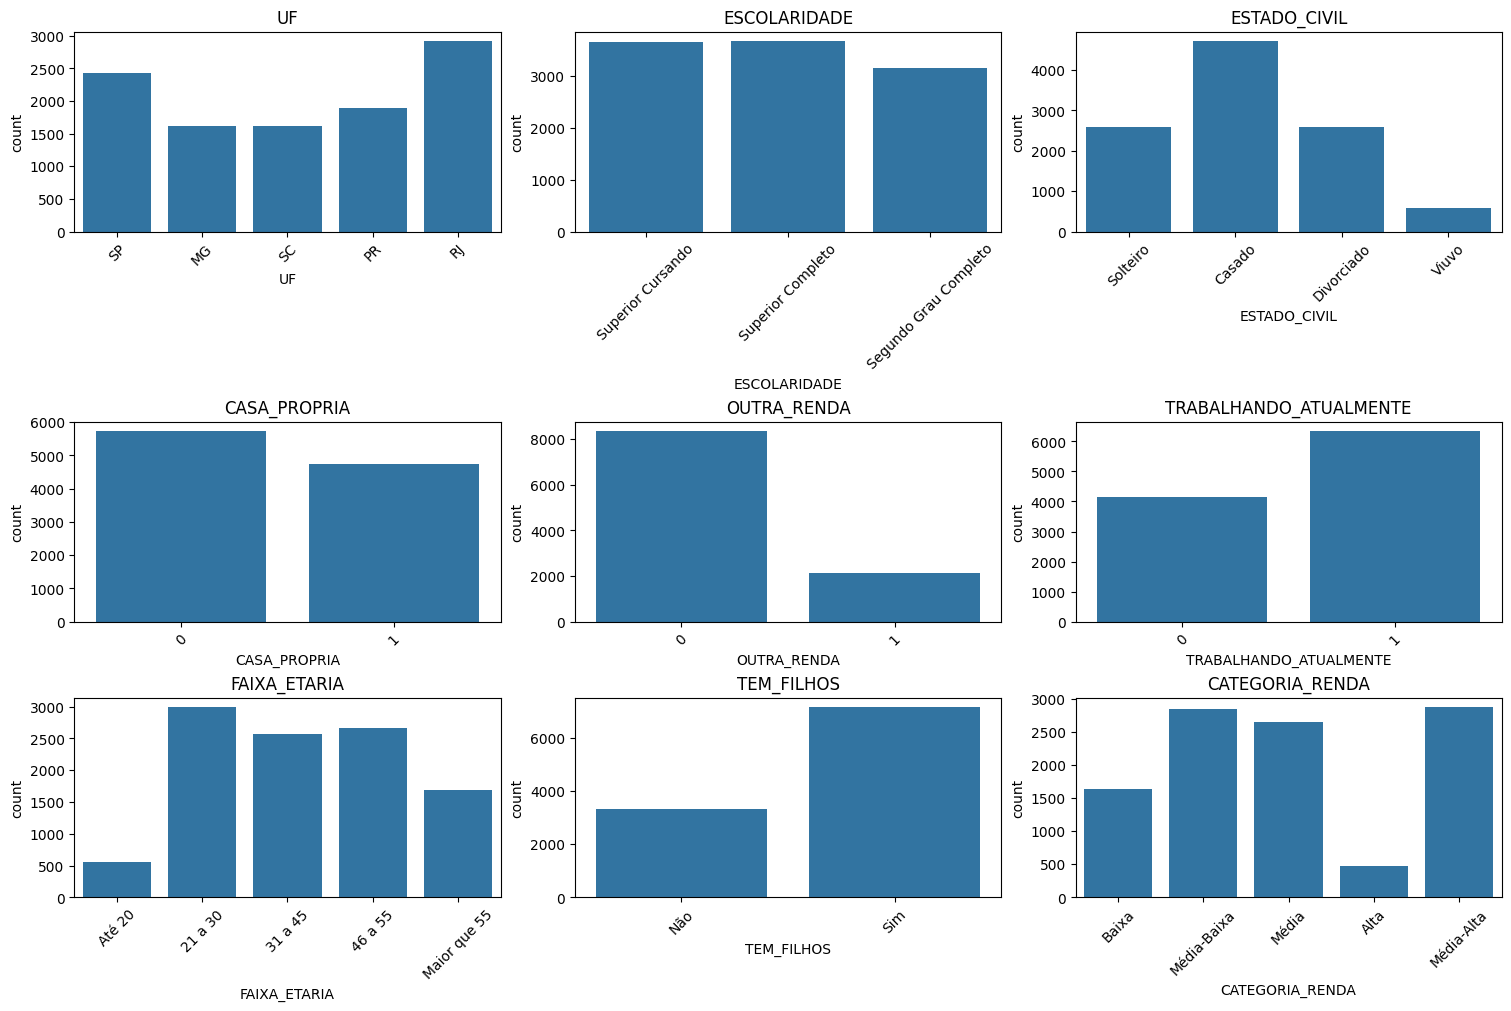

In [16]:
fig, axes = plt.subplots(3, 3, figsize=(15, 10), constrained_layout=True)

for ax, col in zip(axes.flat, cat):
    sns.countplot(data=df, x=col, ax=ax)
    ax.set_title(col)
    ax.tick_params(axis='x', rotation=45)

for ax in axes.flat[len(cat):]:
    ax.set_visible(False)

plt.show()

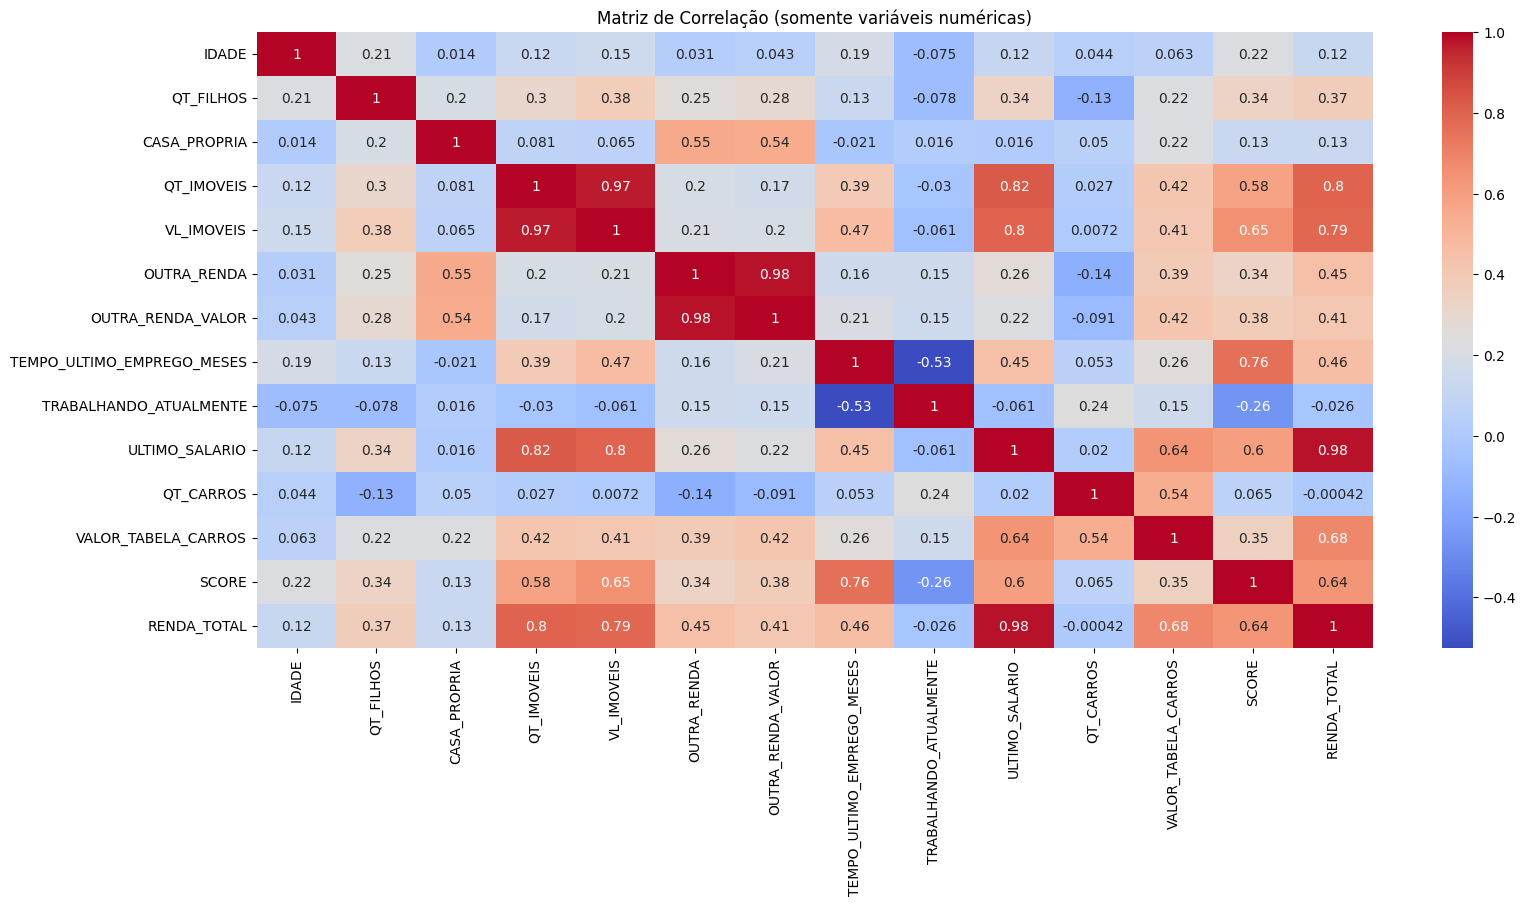

In [17]:
plt.rcParams["figure.figsize"] = (18, 8)

corr = df.select_dtypes(include=[np.number]).corr()

ax = sns.heatmap(corr, annot=True, cmap="coolwarm")
plt.title("Matriz de Correlação (somente variáveis numéricas)")
plt.show()

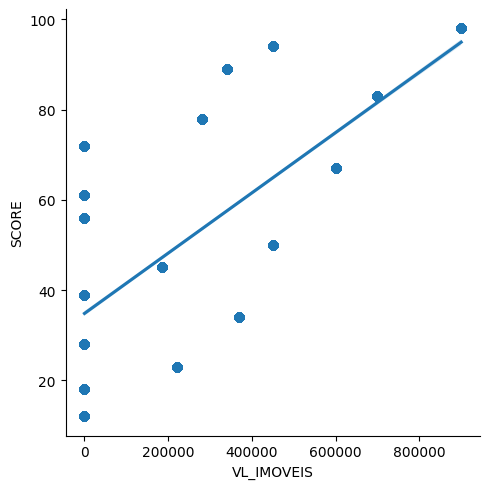

In [18]:
sns.lmplot(x = "VL_IMOVEIS", y = "SCORE", data = df);

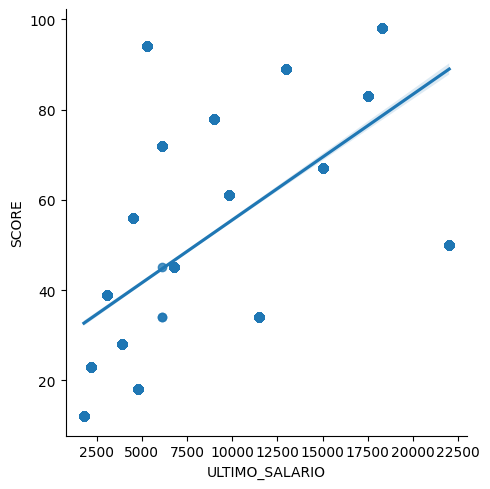

In [19]:
sns.lmplot(x = "ULTIMO_SALARIO", y = "SCORE", data = df);

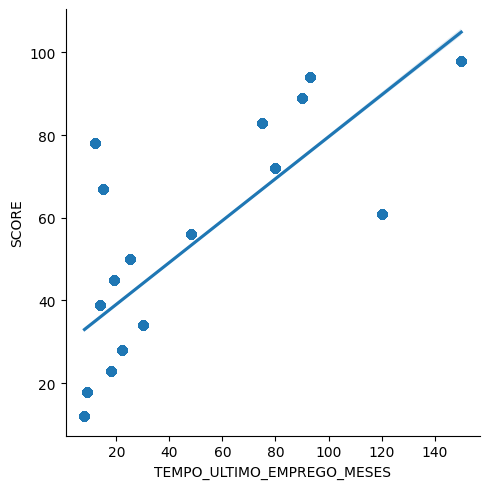

In [20]:
sns.lmplot(x = "TEMPO_ULTIMO_EMPREGO_MESES", y = "SCORE", data = df);

## Processamento dos Dados

In [21]:
lb = LabelEncoder()

df['UF'] = lb.fit_transform(df['UF'])
df['OUTRA_RENDA'] = lb.fit_transform(df['OUTRA_RENDA'])
df['TRABALHANDO_ATUALMENTE'] = lb.fit_transform(df['TRABALHANDO_ATUALMENTE'])
df['ESTADO_CIVIL'] = lb.fit_transform(df['ESTADO_CIVIL'])
df['CASA_PROPRIA'] = lb.fit_transform(df['CASA_PROPRIA'])
df['ESCOLARIDADE'] = lb.fit_transform(df['ESCOLARIDADE'])
df['FAIXA_ETARIA'] = lb.fit_transform(df['FAIXA_ETARIA'])
df['TEM_FILHOS'] = lb.fit_transform(df['TEM_FILHOS'])
df['CATEGORIA_RENDA'] = lb.fit_transform(df['CATEGORIA_RENDA'])

df.dropna(inplace = True)

In [22]:
target = df["SCORE"]

In [23]:
preditoras = df.drop(columns=['SCORE'])

preditoras.head()

,UF,IDADE,ESCOLARIDADE,ESTADO_CIVIL,QT_FILHOS,CASA_PROPRIA,QT_IMOVEIS,VL_IMOVEIS,OUTRA_RENDA,OUTRA_RENDA_VALOR,TEMPO_ULTIMO_EMPREGO_MESES,TRABALHANDO_ATUALMENTE,ULTIMO_SALARIO,QT_CARROS,VALOR_TABELA_CARROS,RENDA_TOTAL,FAIXA_ETARIA,TEM_FILHOS,CATEGORIA_RENDA
0,4,19,2,2,0,0,0,0.0,0,0.0,8,1,1800.0,0,0.0,1800.0,3,0,1
1,0,23,1,2,1,0,0,0.0,0,0.0,9,0,4800.0,1,50000.0,4800.0,0,1,4
2,3,25,0,0,0,1,1,220000.0,0,0.0,18,1,2200.0,2,30000.0,2200.0,0,0,1
3,1,27,2,0,1,1,0,0.0,0,0.0,22,0,3900.0,0,0.0,3900.0,0,1,4
4,2,28,1,1,2,0,1,370000.0,0,0.0,30,1,6100.0,1,35000.0,6100.0,0,1,2


In [24]:
X_treino, X_teste, y_treino, y_teste = train_test_split(preditoras, target, test_size = 0.4, random_state = 3456)

In [25]:
sc = MinMaxScaler()
X_treino_normalizados = sc.fit_transform(X_treino)
X_teste_normalizados = sc.transform(X_teste)

## Criar, avaliar e testar nosso modelo preditivo 

In [26]:
scaler = StandardScaler()
X_treino_normalizados = scaler.fit_transform(X_treino)
X_teste_normalizados = scaler.transform(X_teste)

modelo = LinearRegression(fit_intercept=True)
modelo.fit(X_treino_normalizados, y_treino)

LinearRegression()

In [27]:
r2_score(y_teste, modelo.fit(X_treino_normalizados, y_treino).predict(X_teste_normalizados))

0.7972016161229916